## LSTM for RUL prediction

Importing the necessary libraries

In [68]:
import os
import pandas as pd
import random
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib as mpl

Setting up class for custom dataset

In [69]:
class CustomDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_paths = [os.path.join(data_dir, data) for data in os.listdir(data_dir)]
        self.transform = transform

    def __len__(self):
        return len(self.data_paths)

    def __getitem__(self, idx):
        file_path = self.data_paths[idx]
        data = pd.read_csv(file_path)

        # get feature and make it into the shape [batch_size, seq_len, 1]
        SOHs = torch.tensor(data['SOH'], dtype=torch.float32)
        SOHs = torch.unsqueeze(SOHs, -1)
        if self.transform:
            targets = self.transform(SOHs)

        return SOHs

Building the LSTM model using LSTM cell

In [70]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # Todo: define the LSTM cell
        self.lstm_cell = nn.LSTMCell(input_size=input_size, hidden_size=hidden_size)
        # Todo: define the fully connected layer with Sigmoid activation function
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, output_size),
            nn.Sigmoid(),
        )

        # define initial hidden state and cell state
        self.h_0 = nn.Parameter(torch.zeros(1, hidden_size), requires_grad=True)
        self.c_0 = nn.Parameter(torch.zeros(1, hidden_size), requires_grad=True)

        self.hidden_size = hidden_size
        self.output_size = output_size

    # forward function for training
    def forward(self, inputs, teacher_forcing_ratio=0.5):
        batch_size = inputs.size(0)
        seq_len = inputs.size(1)

        # for training, teacher forcing is used randomly

        # expand initial hidden state and cell state to match batch size
        h_0 = self.h_0.expand(batch_size, self.hidden_size).contiguous().to(inputs.device)
        c_0 = self.c_0.expand(batch_size, self.hidden_size).contiguous().to(inputs.device)

        # initialize predictions tensor
        predictions = torch.zeros(batch_size, seq_len, self.output_size).to(inputs.device)
        h_t, c_t = 0, 0
        output_t = 0

        # iterate over each time step
        for t in range(seq_len):
            # Todo: determine the input for the current time step
            if random.random() > teacher_forcing_ratio and t > 0:   # use previous output as the current input when teacher forcing is not used and not the first time step
                input_t = output_t
            else:                                                   # use ground-truth SOH as the current input when teacher forcing is used or the first time step
                input_t = inputs[:, t, :]

            # Todo: calculate the hidden state and cell state for the current time step
            if t == 0:  # use initial hidden state and cell state for the first time step
                h_t, c_t = self.lstm_cell(input_t, (h_0, c_0))
            else:       # use previous hidden state and cell state for the subsequent time steps
                h_t, c_t = self.lstm_cell(input_t, (h_t, c_t))

            # Todo: map the LSTM hidden state to the output for the current time step using the fully connected layer
            output_t = self.fc(h_t)
            predictions[:, t, :] = output_t # store the output in the predictions tensor

        return predictions

    # inference function for testing
    # history: the available historical SOH data
    # max_len: the maximum length of the prediction sequence
    def inference(self, history, max_len=200):
        batch_size = history.size(0)
        history_len = history.size(1)

        # for inference, predictions are made autorergressively

        # expand initial hidden state and cell state to match batch size
        h_0 = self.h_0.expand(batch_size, self.hidden_size).contiguous().to(history.device)
        c_0 = self.c_0.expand(batch_size, self.hidden_size).contiguous().to(history.device)

        # initialize predictions list
        predictions = []
        h_t, c_t = 0, 0
        output_t = 0

        # iterate over each time step
        for t in range(max_len):
            # Todo: determine the input for the current time step
            if t < history_len: # use ground-truth history SOH value as input if available
                input_t = history[:, t, :]
            else:               # use previous output as input if history SOH is not available
                input_t = output_t

            # Todo: calculate the hidden state and cell state for the current time step
            if t == 0:  # use initial hidden state and cell state for the first time step
                h_t, c_t = self.lstm_cell(input_t, (h_0, c_0))
            else:       # use previous hidden state and cell state for the subsequent time steps
                h_t, c_t = self.lstm_cell(input_t, (h_t, c_t))

            # Todo: determine the output for the current time step
            output_t = self.fc(h_t)
            predictions.append(output_t)    # store the output in the predictions list

        # stack predictions into a tensor with shape [batch_size, seq_len, num_features]
        predictions = torch.cat(predictions, dim=1).unsqueeze(-1).to(history.device)

        return predictions

Training and validation loop functions

In [71]:
def train(model, train_loader, loss_fn, optimizer, device, epoch, num_epochs, train_loss_df):
    num_batches = len(train_loader)
    train_loss = 0

    model.train()
    for batch, SOHs in enumerate(train_loader):
        SOHs = SOHs.to(device)

        # Todo: choose the appropriate slice of the ground-truth SOH sequence as the input sequence and as the target sequence for loss calculation
        inputs = SOHs[:, :-1, :]
        targets = SOHs[:, 1:, :]
        # Todo: forward pass, loss calculation, and backpropagation
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()

        # record loss
        train_loss += loss.item()

        print(f'Batch: {batch+1}/{num_batches}, loss: {loss}')

    avg_train_loss = train_loss / num_batches           # loss averaged over each batch
    train_loss_df.loc[len(train_loss_df)] = [epoch+1, avg_train_loss]

    print(f'Epoch: {epoch+1}/{num_epochs}, average training loss: {avg_train_loss}')


def validate(model, val_loader, loss_fn, device, epoch, num_epochs, val_loss_df):
    num_batches = len(val_loader)
    val_loss = 0

    model.eval()
    with torch.no_grad():
        for SOHs in val_loader:
            SOHs = SOHs.to(device)
            # Todo: choose the appropriate slice of the ground-truth SOH sequence as the input sequence and as the target sequence for loss calculation
            inputs = SOHs[:, :-1, :]
            targets = SOHs[:, 1:, :]
            # Todo: forward pass and loss calculation
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)

            # record loss
            val_loss += loss.item()

        avg_val_loss = val_loss / num_batches           # loss averaged over each batch
        val_loss_df.loc[len(val_loss_df)] = [epoch+1, avg_val_loss]

        print(f'Epoch: {epoch+1}/{num_epochs}, average validation loss: {avg_val_loss}')

Setting up the paths

In [72]:
# based_dir: the root directory of the project
# preprocessed_data_root_path: the path to the preprocessed data
# model_save_path: the path to save the trained model and training logs
# Todo: define the base directory of the project
base_dir = os.path.abspath(os.getcwd())
preprocessed_data_root_path = os.path.join(base_dir, 'data', 'preprocessed')
model_save_root_path = os.path.join(base_dir, 'save')
train_path = os.path.join(preprocessed_data_root_path, 'training')
val_path = os.path.join(preprocessed_data_root_path, 'validation')
test_path = os.path.join(preprocessed_data_root_path, 'test')

Setting up the hyperparameters and device

In [73]:
# Todo: choose the appropriate learning rate and number of epochs. Use the batch size of 1 for simplicity.
learning_rate = 1e-3
num_epochs = 200
batch_size = 1

# Todo: choose the appropriate input size, hidden size, and output size of the LSTM model
input_size = 1
hidden_size = 32
output_size = 1

# Todo: set the device for training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Loading the datasets

In [74]:
# Todo: load the training, validation, and test datasets
train_dataset = CustomDataset(train_path)
val_dataset = CustomDataset(val_path)
test_dataset = CustomDataset(test_path)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Initializing the model, loss function, optimizer, and training logs

In [75]:
# Todo: initialize the LSTM model, loss function, and optimizer
# initialize model
model = LSTM(input_size=input_size, hidden_size=hidden_size, output_size=output_size).to(device)

# define loss function and optimizer
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# initialize dataframe for training and validation loss
train_loss_df = pd.DataFrame(columns=['epoch', 'avg_train_loss'])
val_loss_df = pd.DataFrame(columns=['epoch', 'avg_val_loss'])

### Training and validation

In [76]:
# Todo: train the model and validate it at each epoch
for epoch in range(num_epochs):
    train(model=model, train_loader=train_loader, loss_fn=loss_fn, optimizer=optimizer, device=device,
          epoch=epoch, num_epochs=num_epochs, train_loss_df=train_loss_df)
    validate(model=model, val_loader=val_loader, loss_fn=loss_fn, device=device,
             epoch=epoch, num_epochs=num_epochs, val_loss_df=val_loss_df)

Batch: 1/2, loss: 0.0738491490483284
Batch: 2/2, loss: 0.08951598405838013
Epoch: 1/200, average training loss: 0.08168256655335426
Epoch: 1/200, average validation loss: 0.07131945341825485
Batch: 1/2, loss: 0.071329765021801
Batch: 2/2, loss: 0.0865972638130188
Epoch: 2/200, average training loss: 0.0789635144174099
Epoch: 2/200, average validation loss: 0.06888280063867569
Batch: 1/2, loss: 0.06907368451356888
Batch: 2/2, loss: 0.0836883932352066
Epoch: 3/200, average training loss: 0.07638103887438774
Epoch: 3/200, average validation loss: 0.0664893165230751
Batch: 1/2, loss: 0.06672724336385727
Batch: 2/2, loss: 0.08092312514781952
Epoch: 4/200, average training loss: 0.0738251842558384
Epoch: 4/200, average validation loss: 0.06397578120231628
Batch: 1/2, loss: 0.07953035086393356
Batch: 2/2, loss: 0.06320765614509583
Epoch: 5/200, average training loss: 0.0713690035045147
Epoch: 5/200, average validation loss: 0.061473287642002106
Batch: 1/2, loss: 0.0766696110367775
Batch: 2/2,

Saving the model and training logs

In [77]:
# create a directory for saving
timestamp = time.strftime("%Y%m%d_%H%M%S")
model_save_path = os.path.join(model_save_root_path, timestamp)
os.makedirs(model_save_path, exist_ok=True)

# save the model and training logs
torch.save(model.state_dict(), os.path.join(model_save_path, 'model_state_dict.pth'))
train_loss_df.to_csv(os.path.join(model_save_path, 'train_loss.csv'), index=False)
val_loss_df.to_csv(os.path.join(model_save_path, 'val_loss.csv'), index=False)

### Evaluation

Define the path to the saved logs and model

In [78]:
# Todo: select the desired folder from the save directory
save_dirs = sorted([d for d in os.listdir(model_save_root_path) if os.path.isdir(os.path.join(model_save_root_path, d))])
if not save_dirs:
    raise FileNotFoundError(f'No saved models found in {model_save_root_path}')
model_save_path = os.path.join(model_save_root_path, save_dirs[-1])

Instantiating the model and loading the trained weights on CPU

In [79]:
model = LSTM(input_size=input_size, hidden_size=hidden_size, output_size=output_size).to(device)
model.load_state_dict(torch.load(os.path.join(model_save_path, 'model_state_dict.pth'), map_location=torch.device('cpu')))

<All keys matched successfully>

Visualizing the training and validation loss

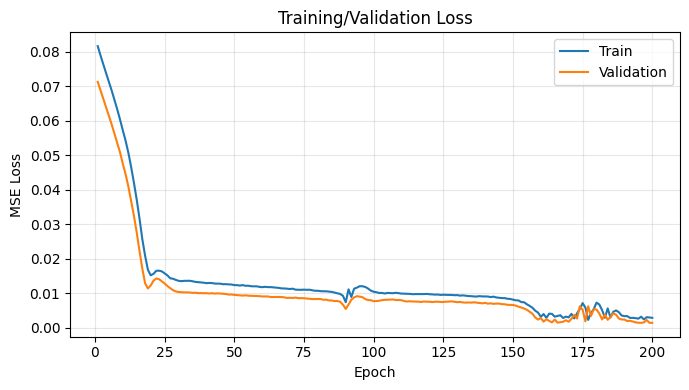

In [80]:
train_loss_df = pd.read_csv(os.path.join(model_save_path, 'train_loss.csv'))
val_loss_df = pd.read_csv(os.path.join(model_save_path, 'val_loss.csv'))

# Todo: plot training and validation loss
plt.figure(figsize=(7, 4))
plt.plot(train_loss_df['epoch'], train_loss_df['avg_train_loss'], label='Train')
plt.plot(val_loss_df['epoch'], val_loss_df['avg_val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training/Validation Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Defining test function

In [81]:
# input:
# model: the trained model
# test_data: the test data
# history_len: the length of the history data to be used for inference
# max_len: the maximum length of the prediction sequence (excluding the initial history point)
# output:
# predictions_np: the predicted SOH values
# mae_np: the mean absolute error between the predictions and the ground truth

def single_test(model, test_data, history_len, max_len=None):
    model.eval()
    SOHs = torch.unsqueeze(test_data.to('cpu'), dim=0)  # add batch dimension

    # Todo: slice the history data from the test data
    history = SOHs[:, :history_len, :]
    # match prediction length to ground truth length if max_len not provided
    if max_len is None:
        max_len = SOHs.size(1) - 1

    with torch.no_grad():
        # Todo: make predictions using the inference function and calculate the mean absolute error
        predictions = model.inference(history, max_len=max_len)
        pred_error_len = min(predictions.size(1), SOHs.size(1)) # the length of the prediction for the error calculation
        mae = F.l1_loss(predictions[:, :pred_error_len, :], SOHs[:, :pred_error_len, :], reduction='mean')

    predictions_np, mae_np = predictions.cpu().numpy().flatten(), mae.cpu().numpy().flatten()

    return predictions_np, mae_np

Testing over B0018

In [82]:
# get the test profile
test_data = test_dataset[0]
print(os.listdir(test_path)[0])

# Todo: set the history length and end of life SOH threshold and run the test
history_len = 60
eol_soh = 0.7
predictions, mae = single_test(model=model, test_data=test_data, history_len=history_len)
print(f'MAE: {mae}')

B0018.csv
MAE: [0.03835437]


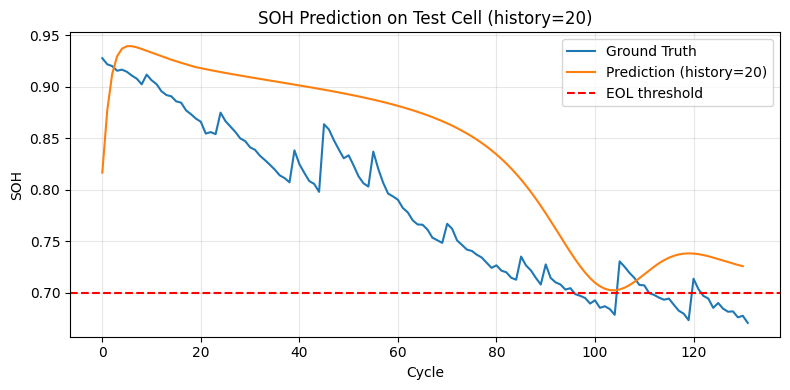

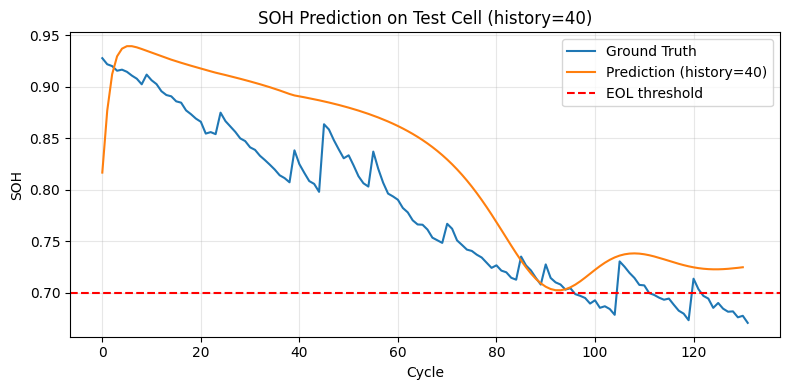

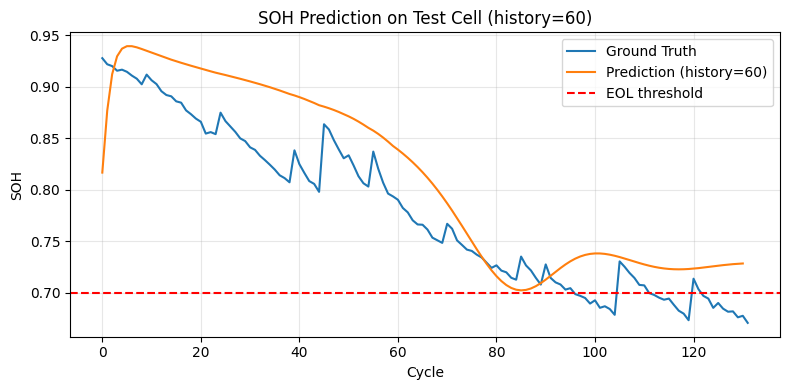

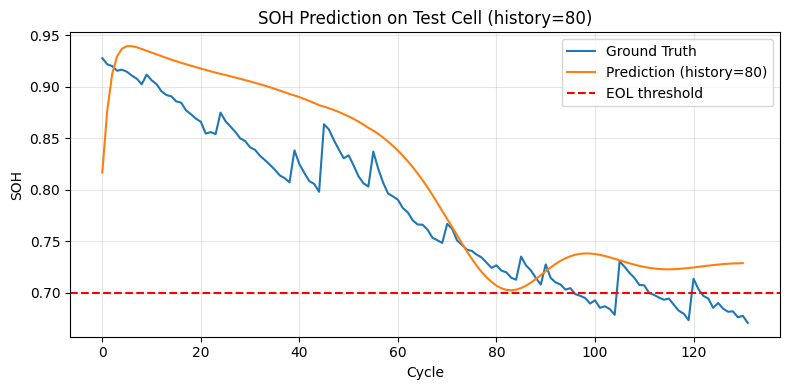

   history_len       mae  gt_rul  pred_rul  rul_error
0           20  0.061141      77       111         34
1           40  0.045521      57        91         34
2           60  0.038354      37        71         34
3           80  0.037714      17        51         34


In [83]:
# Evaluate multiple history lengths
history_lengths = [20, 40, 60, 80]
eol_soh = 0.7
results = []

for h in history_lengths:
    preds, mae = single_test(model=model, test_data=test_data, history_len=h)
    gt_series = test_data.numpy().flatten()
    pred_series = preds
    
    def find_eol_index(series, threshold):
        for i, v in enumerate(series):
            if v <= threshold:
                return i
        return len(series) - 1
    
    gt_eol = find_eol_index(gt_series, eol_soh)
    pred_eol = find_eol_index(pred_series, eol_soh)
    gt_rul = gt_eol - (h - 1)
    pred_rul = pred_eol - (h - 1)
    rul_error = abs(pred_rul - gt_rul)
    results.append((h, float(mae[0]), gt_rul, pred_rul, rul_error))
    
    # Plot curves for each history length
    plt.figure(figsize=(8, 4))
    plt.plot(gt_series, label='Ground Truth')
    plt.plot(pred_series, label=f'Prediction (history={h})')
    plt.axhline(y=eol_soh, color='r', linestyle='--', label='EOL threshold')
    plt.xlabel('Cycle')
    plt.ylabel('SOH')
    plt.title(f'SOH Prediction on Test Cell (history={h})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Print summary table
summary_df = pd.DataFrame(results, columns=['history_len', 'mae', 'gt_rul', 'pred_rul', 'rul_error'])
print(summary_df)

**Kommentar/mögliche Erkläruhg, dass prediction der ground truth entspricht im Zeitfenster history**
Während inference wird dem Modell explizit ground-truth für all timesteps t > len(history) vorgegeben.
Input setzt bei t < history_len die Ground‑Truth‑History (input_t = history[:, t, :]).
Output setzt bei (t + 1) < history_len die nächste Ground‑Truth‑History (output_t = history[:, t + 1, :])

Visualizing the predicted and ground-truth degradation curves and calculating the RUL

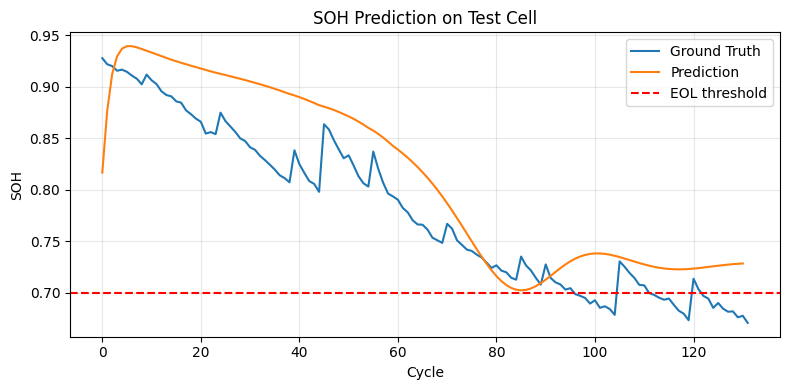

GT RUL: 37, Pred RUL: 71, RUL Error: 34


In [84]:
# Todo: plot the predicted and ground-truth SOH values
gt = test_data.numpy().flatten()
pred = predictions
plt.figure(figsize=(8, 4))
plt.plot(gt, label='Ground Truth')
plt.plot(pred, label='Prediction')
plt.axhline(y=eol_soh, color='r', linestyle='--', label='EOL threshold')
plt.xlabel('Cycle')
plt.ylabel('SOH')
plt.title('SOH Prediction on Test Cell')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Todo: calculate the RULs and the error
def find_eol_index(series, threshold):
    for i, v in enumerate(series):
        if v <= threshold:
            return i
    return len(series) - 1

gt_eol = find_eol_index(gt, eol_soh)
pred_eol = find_eol_index(pred, eol_soh)
gt_rul = gt_eol - (history_len - 1)
pred_rul = pred_eol - (history_len - 1)
rul_error = abs(pred_rul - gt_rul)
print(f'GT RUL: {gt_rul}, Pred RUL: {pred_rul}, RUL Error: {rul_error}')

In [85]:
# print out all hyperparameters
print(f'Learning Rate: {learning_rate}')
print(f'Number of Epochs: {num_epochs}')
print(f'Batch Size: {batch_size}')
print(f'Input Size: {input_size}')
print(f'Hidden Size: {hidden_size}')
print(f'Output Size: {output_size}')

Learning Rate: 0.001
Number of Epochs: 200
Batch Size: 1
Input Size: 1
Hidden Size: 32
Output Size: 1
